In [ ]:
# Capstone 1 – Sentiment Analysis of Malaysian Tweets for Mental Health Detection
# Author: Siobhan Goh Shze Mun | Dataset: cleaned_tweets_sentiments.csv | June 2025

# Step 1: Mount Google Drive and Load Dataset
# Mounts Google Drive to access the dataset, then loads the tweet data into a pandas DataFrame.

from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df_org = pd.read_csv('/content/drive/My Drive/Colab Notebooks/cleaned_tweets_sentiments.csv')
print(df_org.head().to_string())

Mounted at /content/drive
                                                                                                                                                                                                       Tweet Sentiment
0                                                                                                                                                                              social distancing done right   POSITIVE
1  deepaavali 2020 day 2 thaaimaman house family dinner #deepaavali #2020goals #love #celebration #festivaloflights #goodvibes #familytime #moment #gettogether #socialdistancing #day2 layang layang johor   POSITIVE
2                                                                                                                        kluster najib apa sik saman terus sidak semua sia sikda social distancing gk https   NEGATIVE
3                                                                                                                 

In [ ]:
# Step 2: Explore DataFrame Structure
# Displays the first few rows and column names to understand the dataset layout.

df = df_org.copy()
print(df.head())
print(df.columns)

                                               Tweet Sentiment
0                      social distancing done right   POSITIVE
1  deepaavali 2020 day 2 thaaimaman house family ...  POSITIVE
2  kluster najib apa sik saman terus sidak semua ...  NEGATIVE
3  ju yy that s the unique part of our compoundin...   NEUTRAL
4                       cherating #socialdistancing    NEUTRAL
Index(['Tweet', 'Sentiment'], dtype='object')


In [ ]:
# Step 3: Analyze Sentiment Distribution
# Counts the number of tweets per sentiment class to understand class balance.

df['Sentiment'].value_counts()

,count
Sentiment,
NEGATIVE,2779
POSITIVE,2322
NEUTRAL,1898


In [ ]:
# Step 4: Preprocess and Clean Tweet Text
# Cleans each tweet by removing URLs, punctuation, and stopwords. Converts all text to lowercase.

import nltk
import re
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                                # lowercase
    text = re.sub(r"http\S+|www\S+|@\w+|[^a-zA-Z\s]", "", text)  # remove URLs, mentions, punctuation
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(tokens)

df['Processed_Tweet'] = df['Tweet'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Step 5: Convert Tweets to TF-IDF Features
# Transforms processed text into numerical features using Term Frequency-Inverse Document Frequency.

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['Processed_Tweet'])

In [ ]:
# Step 6: Encode Sentiment Labels
# Converts sentiment class labels (POSITIVE, NEUTRAL, NEGATIVE) into numeric codes for modeling.

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['Sentiment'])  # e.g., 'NEGATIVE' → 0, 'NEUTRAL' → 1, 'POSITIVE' → 2

In [ ]:
# Step 7a: Logistic Regression Model Training and Evaluation

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate Model Performance
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

    NEGATIVE       0.64      0.74      0.69       558
     NEUTRAL       0.61      0.61      0.61       376
    POSITIVE       0.64      0.52      0.58       466

    accuracy                           0.63      1400
   macro avg       0.63      0.62      0.62      1400
weighted avg       0.63      0.63      0.63      1400



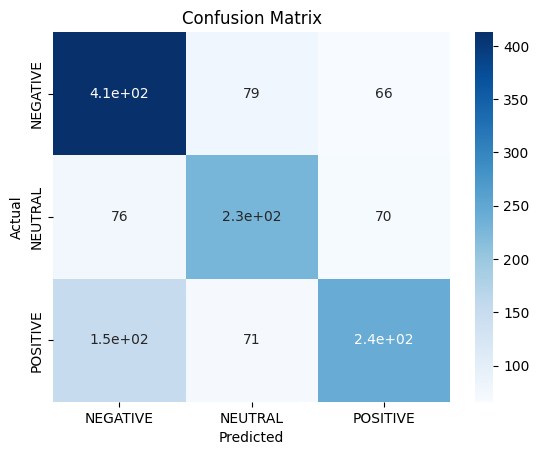

In [ ]:
# Step 7b: Confusion Matrix

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True,
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

/tmp/ipython-input-1617098706.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', order=['POSITIVE', 'NEUTRAL', 'NEGATIVE'], palette='pastel')


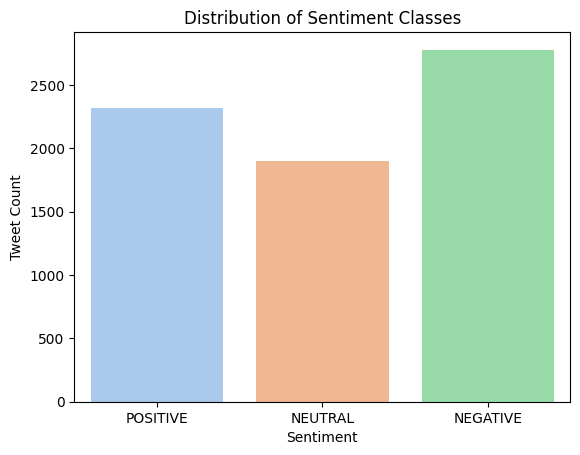

In [ ]:
# Step 8:  Visualize Sentiment Class Distribution
# Shows how many tweets fall into each sentiment category using a bar plot.

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Sentiment', order=['POSITIVE', 'NEUTRAL', 'NEGATIVE'], palette='pastel')
plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Count")
plt.show()

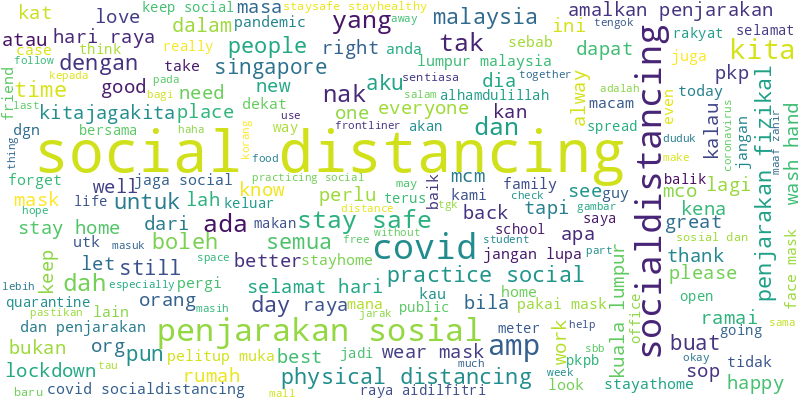

In [ ]:
# Step 9: Word Cloud Generation
# Combines all cleaned tweets by sentiment and generates word clouds to visualize most frequent words.
!pip install wordcloud

from wordcloud import WordCloud

# Combine all tweets by class
positive_text = " ".join(df[df['Sentiment'] == 'POSITIVE']['Processed_Tweet'])
neutral_text = " ".join(df[df['Sentiment'] == 'NEUTRAL']['Processed_Tweet'])
negative_text = " ".join(df[df['Sentiment'] == 'NEGATIVE']['Processed_Tweet'])

# POSITIVE Word Cloud
WordCloud(width=800, height=400, background_color='white').generate(positive_text).to_image()

In [ ]:
#Summary and Observations
# Reflects on model accuracy and the value of sentiment classification in monitoring online emotional trends.

# The model achieved ~63% accuracy and was able to differentiate positive, neutral, and negative tweets in Malaysia.
# This simple NLP pipeline can serve as a starting point for more advanced mental health signal detection in social media.

In [ ]:
# Step 10.1: Train and Evaluate Naive Bayes Model
# Uses Multinomial Naive Bayes to classify sentiments. Suitable for text data with word frequency features.

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("🔹Naive Bayes Results:")
print(classification_report(y_test, nb_pred, target_names=le.classes_))

🔹Naive Bayes Results:
              precision    recall  f1-score   support

    NEGATIVE       0.64      0.72      0.68       558
     NEUTRAL       0.54      0.77      0.64       376
    POSITIVE       0.69      0.35      0.46       466

    accuracy                           0.61      1400
   macro avg       0.62      0.61      0.59      1400
weighted avg       0.63      0.61      0.59      1400



In [ ]:
# Step 10.2: Train and Evaluate Support Vector Machine (SVM) Model
# Applies a linear support vector classifier to identify sentiment patterns. Performs well in text classification.

from sklearn.svm import LinearSVC

# Train SVM model
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

# Predict with SVM
svm_pred = svm_model.predict(X_test)

# Evaluate SVM
print("🔹 SVM Model Results:")
from sklearn.metrics import classification_report
print(classification_report(y_test, svm_pred, target_names=le.classes_))

🔹 SVM Model Results:
              precision    recall  f1-score   support

    NEGATIVE       0.66      0.70      0.68       558
     NEUTRAL       0.59      0.65      0.62       376
    POSITIVE       0.61      0.53      0.57       466

    accuracy                           0.63      1400
   macro avg       0.62      0.62      0.62      1400
weighted avg       0.63      0.63      0.63      1400



In [ ]:
# Step 10.3: Train and Evaluate Random Forest Model
# A tree-based ensemble method that aggregates many decision trees to improve accuracy and reduce overfitting.

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("🔹 Random Forest Results:")
print(classification_report(y_test, rf_pred, target_names=le.classes_))

🔹 Random Forest Results:
              precision    recall  f1-score   support

    NEGATIVE       0.65      0.79      0.71       558
     NEUTRAL       0.62      0.66      0.64       376
    POSITIVE       0.70      0.47      0.56       466

    accuracy                           0.65      1400
   macro avg       0.65      0.64      0.64      1400
weighted avg       0.66      0.65      0.64      1400



In [ ]:
# Step 10.4a: Train and Evaluate XGBoost Model
# Gradient boosting framework that builds models sequentially and is effective for structured and unstructured data.

!pip install xgboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("🔹 XGBoost Results:")
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [09:14:28] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔹 XGBoost Results:
              precision    recall  f1-score   support

    NEGATIVE       0.68      0.73      0.70       558
     NEUTRAL       0.62      0.74      0.67       376
    POSITIVE       0.70      0.52      0.60       466

    accuracy                           0.66      1400
   macro avg       0.67      0.66      0.66      1400
weighted avg       0.67      0.66      0.66      1400



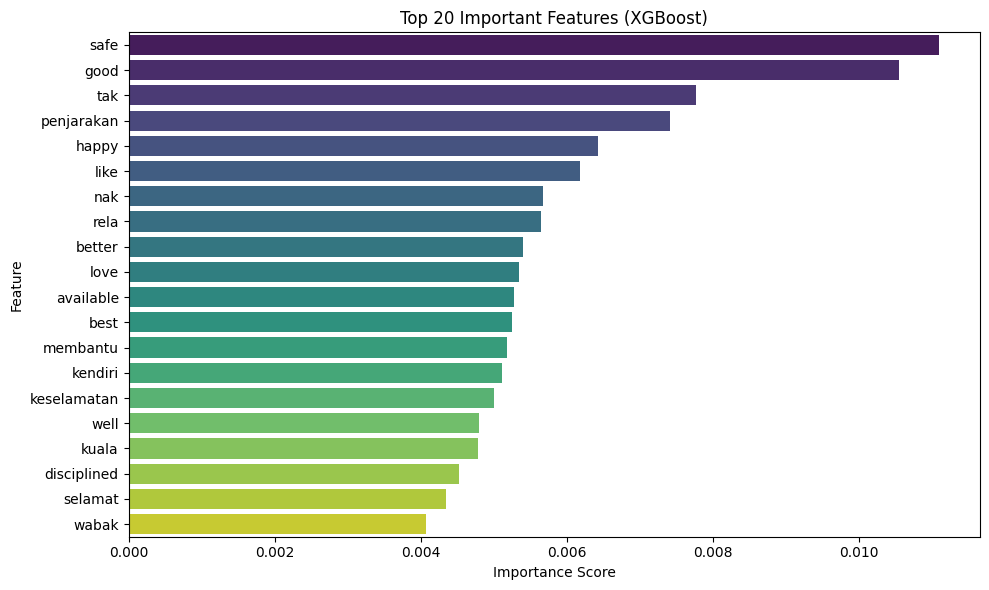

In [ ]:
# Step 10.4b: Visualize Top 20 Most Important Features from XGBoost
# Displays a bar chart of the 20 features (words) with highest importance scores, based on the trained XGBoost model.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance values from XGBoost
importances = xgb_model.feature_importances_
features = vectorizer.get_feature_names_out()

# Create a DataFrame and sort
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

# Plot top 20 features
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    y='Feature',
    x='Importance',
    hue='Feature',         # Add this
    dodge=False,           # To avoid multiple bars per feature
    palette='viridis',
    legend=False           # Since hue is just for color, hide legend
)
plt.title('Top 20 Important Features (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Step 10.5: Train and Evaluate K-Nearest Neighbors (KNN) Model
# A distance-based algorithm that classifies tweets based on the closest neighbors in the feature space.

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("🔹 K-Nearest Neighbors Results:")
print(classification_report(y_test, knn_pred, target_names=le.classes_))

🔹 K-Nearest Neighbors Results:
              precision    recall  f1-score   support

    NEGATIVE       0.57      0.17      0.26       558
     NEUTRAL       0.34      0.72      0.46       376
    POSITIVE       0.43      0.41      0.42       466

    accuracy                           0.40      1400
   macro avg       0.45      0.43      0.38      1400
weighted avg       0.46      0.40      0.37      1400



In [ ]:
# Step 10.6: Train and Evaluate Decision Tree Classifier
# A simple tree-based model that splits data based on feature values to classify tweet sentiment.

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("🔹 Decision Tree Results:")
print(classification_report(y_test, dt_pred, target_names=le.classes_))

🔹 Decision Tree Results:
              precision    recall  f1-score   support

    NEGATIVE       0.62      0.59      0.61       558
     NEUTRAL       0.55      0.64      0.59       376
    POSITIVE       0.56      0.53      0.54       466

    accuracy                           0.58      1400
   macro avg       0.58      0.58      0.58      1400
weighted avg       0.58      0.58      0.58      1400



In [ ]:
# Step 10.7: Train and Evaluate AdaBoost Classifier
# An ensemble model that combines many weak learners to form a stronger classifier.

from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)

ada_pred = ada_model.predict(X_test)

print("🔹 AdaBoost Results:")
print(classification_report(y_test, ada_pred, target_names=le.classes_))

🔹 AdaBoost Results:
              precision    recall  f1-score   support

    NEGATIVE       0.62      0.59      0.61       558
     NEUTRAL       0.54      0.40      0.46       376
    POSITIVE       0.43      0.54      0.48       466

    accuracy                           0.52      1400
   macro avg       0.53      0.51      0.51      1400
weighted avg       0.53      0.52      0.52      1400



In [ ]:
# Step 10.8: Train and Evaluate Gradient Boosting Classifier
# Another boosting model that builds weak learners sequentially, minimizing error at each step.

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("🔹 Gradient Boosting Results:")
print(classification_report(y_test, gb_pred, target_names=le.classes_))

🔹 Gradient Boosting Results:
              precision    recall  f1-score   support

    NEGATIVE       0.63      0.75      0.69       558
     NEUTRAL       0.60      0.68      0.64       376
    POSITIVE       0.71      0.47      0.57       466

    accuracy                           0.64      1400
   macro avg       0.65      0.63      0.63      1400
weighted avg       0.65      0.64      0.63      1400



In [ ]:
# Step 10.9: Train and Evaluate LightGBM Model
# LightGBM is an efficient gradient boosting framework that often performs well in text classification.
!pip install lightgbm
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier()
lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)

print("🔹 LightGBM Results:")
print(classification_report(y_test, lgb_pred, target_names=le.classes_))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023558 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14640
[LightGBM] [Info] Number of data points in the train set: 5599, number of used features: 655
[LightGBM] [Info] Start training from score -0.924630
[LightGBM] [Info] Start training from score -1.302563
[LightGBM] [Info] Start training from score -1.104164
🔹 LightGBM Results:
              precision    recall  f1-score   support

    NEGATIVE       0.66      0.73      0.69       558
     NEUTRAL       0.62      0.68      0.65       376
    POSITIVE       0.69      0.55      0.61       466

    accuracy                           0.66      1400
   macro avg       0.66      0.65      0.65      1400
weighted avg       0.66      0.66      0.65      1400



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Step 11: Model Comparison Summary (Manual Evaluation Table)

#| Model               | Accuracy | F1-Negative | F1-Neutral | F1-Positive |
#|---------------------|----------|-------------|-------------|--------------|
#| Logistic Regression | 63%      | 0.69        | 0.61        | 0.58         |
#| SVM (LinearSVC)     | 63%      | 0.68        | 0.62        | 0.57         |
#| Naive Bayes         | 60%      | —           | —           | —            |
#| Random Forest       | 65%      | 0.71        | 0.64        | 0.56         |
#| XGBoost             | 66%      | 0.70        | 0.67        | 0.60         |
#| K-Nearest Neighbors | 40%      | 0.26        | 0.46        | 0.42         |
#| Decision Tree       | 58%      | 0.61        | 0.59        | 0.54         |
#| AdaBoost            | 52%      | 0.61        | 0.46        | 0.48         |
#| Gradient Boosting   | 64%      | 0.69        | 0.64        | 0.57         |
#| LightGBM            | 66%      | 0.69        | 0.65        | 0.61         |


# Best performing models: LightGBM and XGBoost – highest accuracy (66%) and most balanced F1-scores
# Worst performing model: K-Nearest Neughbors (KNN) - accuracy of 40% only (normal for sparse, high-dimensional text data)
# OK-performance models: Random Forest (65%) and Gradient Boosting (64%): Also strong, especially for NEGATIVE and NEUTRAL

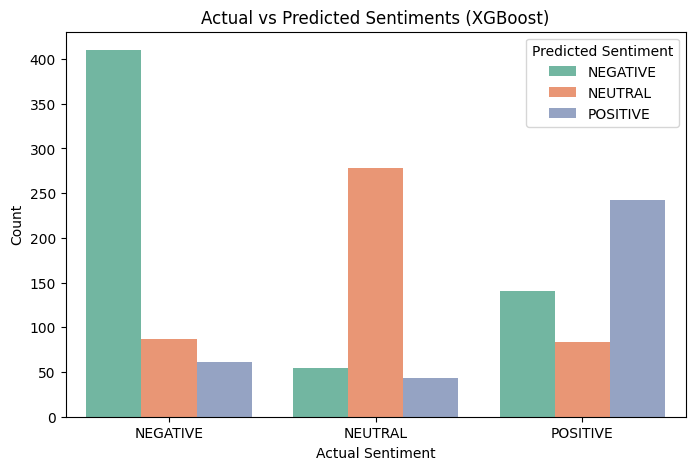

In [ ]:
# Step 12: Visualize Actual vs Predicted Sentiments (XGBoost)
# A count plot showing how XGBoost’s predictions align with actual sentiment labels.

df_xgb = pd.DataFrame({'Actual': y_test, 'Predicted': xgb_pred})
df_xgb = df_xgb.replace({0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'})

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=df_xgb, x='Actual', hue='Predicted', palette='Set2',
              order=['NEGATIVE', 'NEUTRAL', 'POSITIVE'])
plt.title("Actual vs Predicted Sentiments (XGBoost)")
plt.xlabel("Actual Sentiment")
plt.ylabel("Count")
plt.legend(title="Predicted Sentiment")
plt.show()

/tmp/ipython-input-3617767080.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, x='Model', y='Accuracy', palette='viridis')


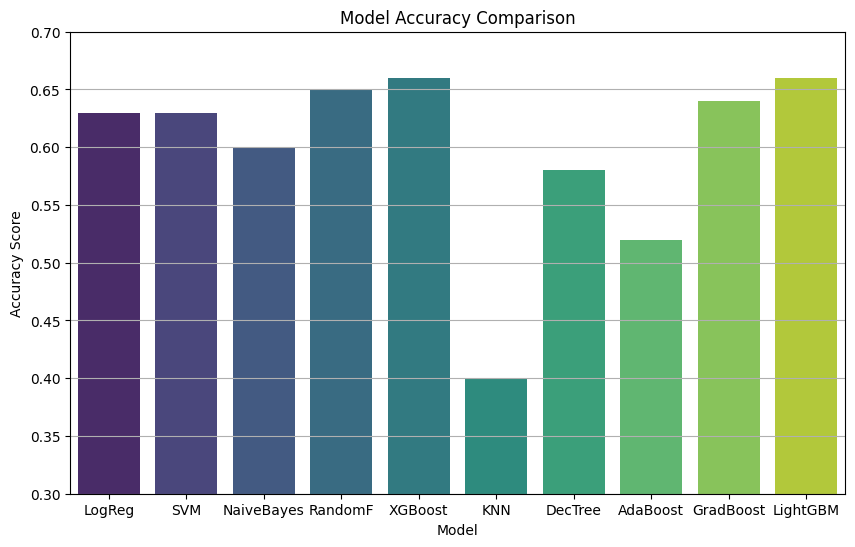

In [ ]:
# Step 13: Plot Overall Model Accuracy Comparison
# A bar chart showing accuracy scores for all tested models for easy performance comparison.

model_scores = {
    'Model': ['LogReg', 'SVM', 'NaiveBayes', 'RandomF', 'XGBoost', 'KNN', 'DecTree', 'AdaBoost', 'GradBoost', 'LightGBM'],
    'Accuracy': [0.63, 0.63, 0.60, 0.65, 0.66, 0.40, 0.58, 0.52, 0.64, 0.66]
}
model_df = pd.DataFrame(model_scores)

plt.figure(figsize=(10, 6))
sns.barplot(data=model_df, x='Model', y='Accuracy', palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0.3, 0.7)
plt.ylabel('Accuracy Score')
plt.xlabel('Model')
plt.grid(axis='y')
plt.show()